# EDA — Predicting O-Level Mathematics `final_test` Scores

**Dataset:** `data/regression_bonus_practice_data.csv` — 15,900 student records, 18 columns.
**Task type:** supervised **regression**.
**Target:** `final_test` — the O-level mathematics examination score (32–100).

**Business problem.** The school wants to identify weaker students *before* the
examination so that support can be directed at them. That framing matters for how we
evaluate: an error of 5 marks on a student near the pass boundary costs more than the
same error on a top scorer, so we care about MAE/RMSE in the low tail, not just
aggregate R².

This notebook mirrors the pipeline in `src/`. Each section states the question, runs
the analysis, and records the decision that the pipeline then implements.

## Section 1 — Setup & Data Load

We load the raw file through the same `DataDownloader` the pipeline uses, so the
notebook and `src/Compiler.py` can never drift apart on how data is read.

In [49]:
import sys, os
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from DataDownloader import DataDownloader
from DataProfiler import DataProfiler
from DataCleaner import DataCleaner
from DataTransformer import DataTransformer
from DataSelector import DataSelector

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

TARGET = 'final_test'

df_raw = DataDownloader(filepath='data/regression_bonus_practice_data.csv').data_load()
df = df_raw.copy()
df.head()

[ok] Loaded 15,900 rows x 18 columns from data/regression_bonus_practice_data.csv


,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,NaN,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow


**Confirmed:** 15,900 rows × 18 columns. One row per student *record* — note that
`student_id` is **not** unique, which Section 2 investigates.

## Section 2 — Data Profiling

We first profile the dataset to understand missing values, data types, and
cardinality before any cleaning. Nothing is modified in this section.

In [50]:
profiler = DataProfiler(df)
profiler.profile()

,count,dtype,n_unique,n_missing,n_missing%
index,15900,int64,15900,0,0.00
number_of_siblings,15900,int64,3,0,0.00
direct_admission,15900,str,2,0,0.00
CCA,12071,str,7,3829,24.08
learning_style,15900,str,2,0,0.00
student_id,15900,str,15000,0,0.00
gender,15900,str,2,0,0.00
tuition,15900,str,4,0,0.00
final_test,15405,float64,68,495,3.11
n_male,15900,float64,32,0,0.00


In [51]:
# Duplicates: whole-row, and on the natural key
print(profiler.duplicate_summary(subset=['student_id']))
print()
print('rows sharing a student_id:', df.duplicated(subset=['student_id'], keep=False).sum())
df[df.duplicated(subset=['student_id'], keep=False)].sort_values('student_id').head(6)

{'n_rows': 15900, 'n_duplicate_rows': 0, 'subset': ['student_id'], 'n_duplicate_subset': 900}

rows sharing a student_id: 1800


,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
5534,5534,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,green
12290,12290,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,white
12270,12270,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
13541,13541,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
4303,4303,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.0,12.0,9.0,15.0,17.0,97.0,22:00,6:00,private transport,yellow
9172,9172,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.0,12.0,9.0,15.0,17.0,97.0,22:00,6:00,private transport,green


In [52]:
profiler.numeric_summary()

,count,mean,std,min,25%,50%,75%,max
index,15900.0,7949.500000,4590.078975,0.0,3974.75,7949.5,11924.25,15899.0
number_of_siblings,15900.0,0.886541,0.751346,0.0,0.00,1.0,1.00,2.0
final_test,15405.0,67.165401,13.977879,32.0,56.00,68.0,78.00,100.0
n_male,15900.0,13.880000,6.552584,0.0,10.00,14.0,18.00,31.0
n_female,15900.0,8.906038,6.663852,0.0,4.00,8.0,13.00,31.0
age,15900.0,15.213459,1.758941,-5.0,15.00,15.0,16.00,16.0
hours_per_week,15900.0,10.312579,4.461861,0.0,7.00,9.0,14.00,20.0
attendance_rate,15122.0,93.270268,7.984230,40.0,92.00,95.0,97.00,100.0


In [53]:
profiler.outlier_summary()

,lower_fence,upper_fence,n_outliers,min,max,missing
index,-7949.5,23848.5,0.0,0.0,15899.0,0.0
number_of_siblings,-1.5,2.5,0.0,0.0,2.0,0.0
final_test,23.0,111.0,0.0,32.0,100.0,495.0
n_male,-2.0,30.0,4.0,0.0,31.0,0.0
n_female,-9.5,26.5,195.0,0.0,31.0,0.0
age,13.5,17.5,451.0,-5.0,16.0,0.0
hours_per_week,-3.5,24.5,0.0,0.0,20.0,0.0
attendance_rate,84.5,104.5,848.0,40.0,100.0,778.0


**Key observations.**

- **No whole-row duplicates**, but **900 rows share a `student_id`** with another row.
  Inspecting them shows they are byte-identical re-entries apart from the occasional
  `bag_color`. These are duplicated *students*, not duplicated observations — if left
  in, the same student can appear in both train and test and inflate the score.
- **Missing values in three columns only:** `CCA` (3,829 ≈ 24%), `attendance_rate`
  (778 ≈ 4.9%), `final_test` (495 ≈ 3.1%).
- **`age` contains impossible values:** negatives (−4, −5) and single digits (5, 6).
- `student_id` and `index` are identifiers with no predictive content.

These findings drive every cleaning step below.

## Section 3 — Univariate Analysis

We examine each feature's distribution independently to identify skew, outliers,
and encoding needs.

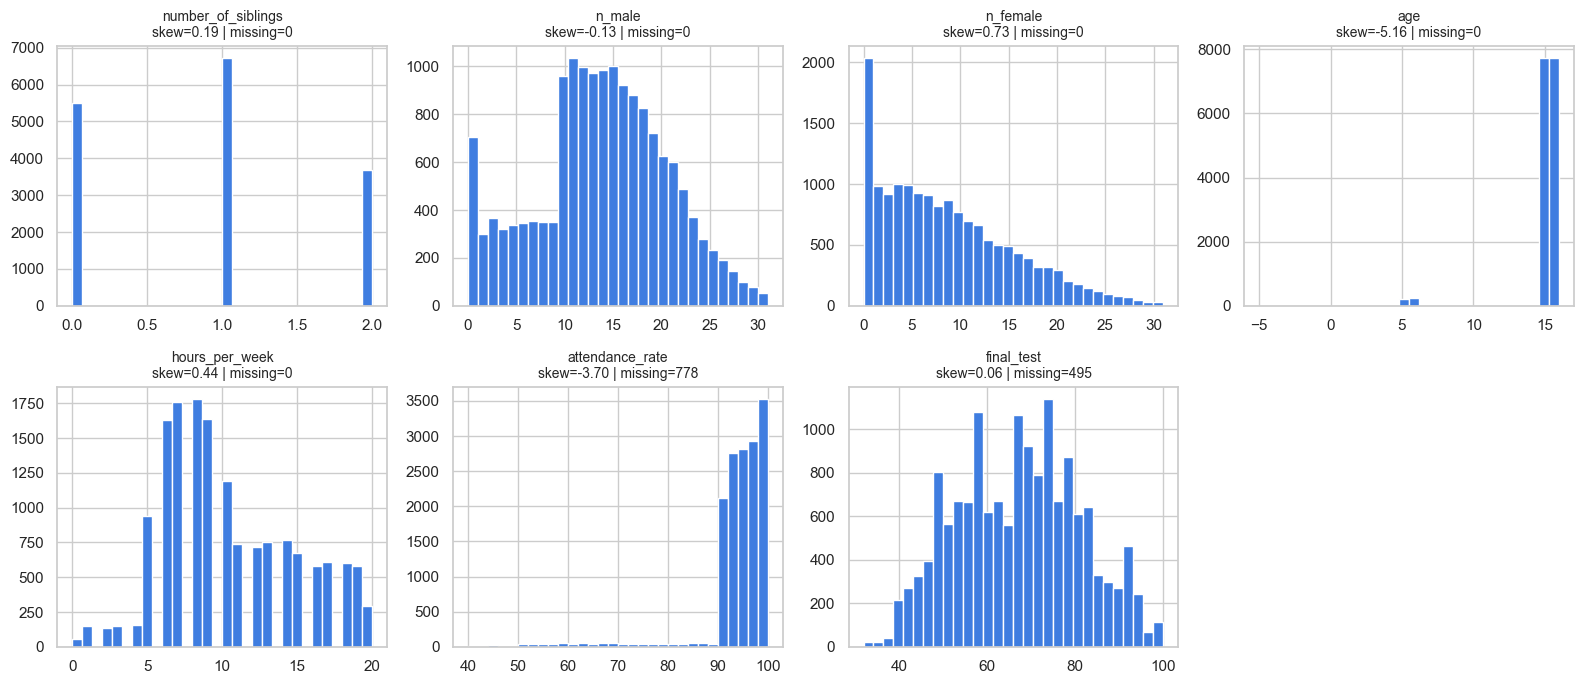

In [54]:
num_cols = ['number_of_siblings', 'n_male', 'n_female', 'age',
            'hours_per_week', 'attendance_rate', TARGET]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, num_cols):
    ax.hist(df[c].dropna(), bins=30, color='#3F7DE0', edgecolor='white')
    ax.set_title(f'{c}\nskew={df[c].skew():.2f} | missing={df[c].isna().sum():,}', fontsize=10)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

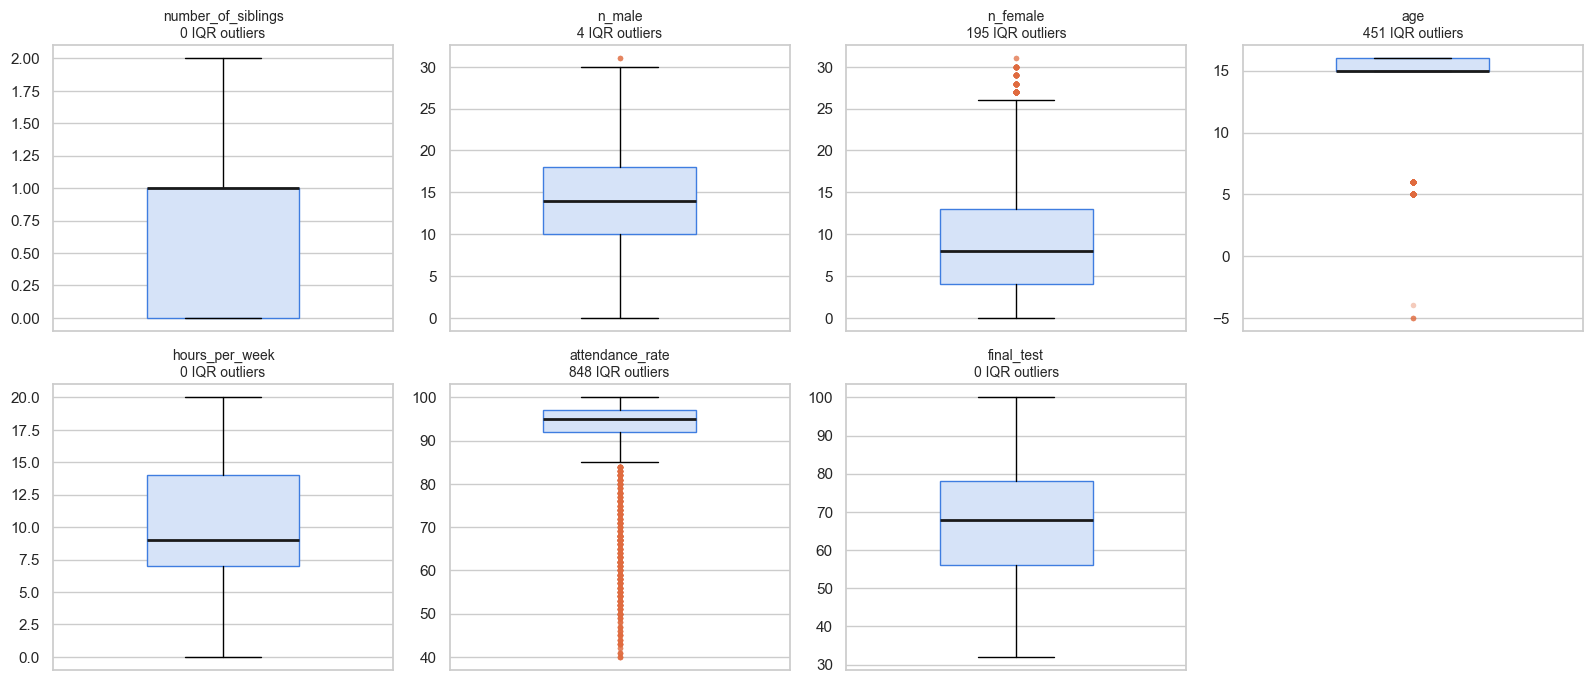

In [55]:
# Boxplots make the age defect and the attendance tail obvious
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, num_cols):
    s = df[c].dropna()
    ax.boxplot(s, widths=.45, patch_artist=True,
               boxprops=dict(facecolor='#D6E3F8', edgecolor='#3F7DE0'),
               medianprops=dict(color='#1a1a1a', linewidth=2),
               flierprops=dict(marker='o', markersize=4, markerfacecolor='#E06B3F',
                               markeredgecolor='none', alpha=.35))
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    ax.set_title(f'{c}\n{n_out:,} IQR outliers', fontsize=10)
    ax.set_xticks([])
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

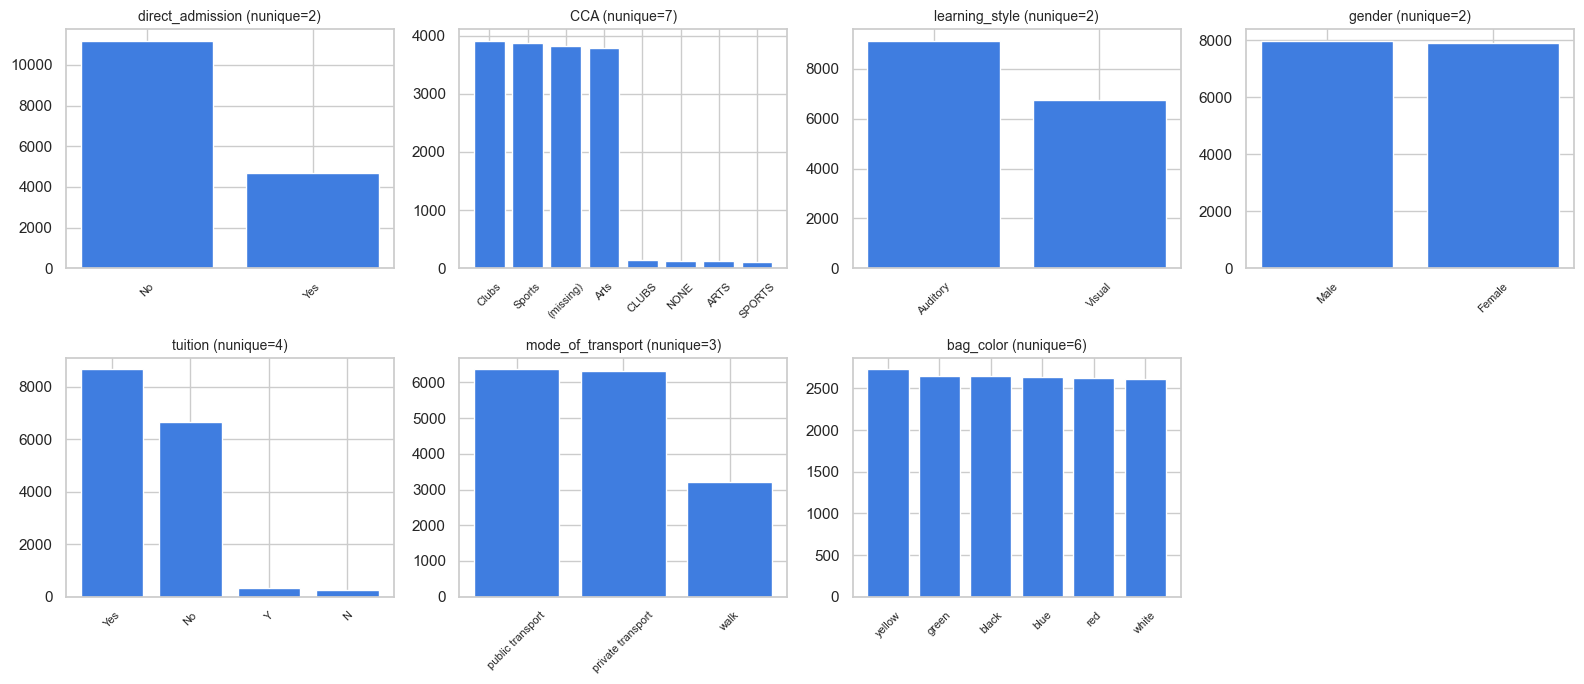

== direct_admission | missing=0
direct_admission
No     11195
Yes     4705 

== CCA | missing=3,829
CCA
Clubs     3912
Sports    3865
NaN       3829
Arts      3785
CLUBS      143
NONE       130
ARTS       128
SPORTS     108 

== learning_style | missing=0
learning_style
Auditory    9132
Visual      6768 

== gender | missing=0
gender
Male      7984
Female    7916 

== tuition | missing=0
tuition
Yes    8669
No     6643
Y       327
N       261 

== mode_of_transport | missing=0
mode_of_transport
public transport     6371
private transport    6323
walk                 3206 

== bag_color | missing=0
bag_color
yellow    2731
green     2653
black     2650
blue      2634
red       2620
white     2612 



In [56]:
cat_cols = ['direct_admission', 'CCA', 'learning_style', 'gender',
            'tuition', 'mode_of_transport', 'bag_color']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, cat_cols):
    vc = df[c].value_counts(dropna=False)
    labels = ['(missing)' if pd.isna(i) else str(i) for i in vc.index]
    ax.bar(labels, vc.values, color='#3F7DE0')
    ax.set_title(f'{c} (nunique={df[c].nunique()})', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

for c in cat_cols:
    print(f'== {c} | missing={df[c].isna().sum():,}')
    print(df[c].value_counts(dropna=False).to_string(), '\n')

In [57]:
# The two clock columns are strings, not durations
print(df['sleep_time'].value_counts().to_string())
print()
print(df['wake_time'].value_counts().to_string())

sleep_time
23:00    3131
22:00    3067
22:30    3034
21:00    2953
21:30    2875
0:00      240
23:30     183
1:00      122
0:30       93
2:00       81
1:30       73
2:30       25
3:00       23

wake_time
5:00    3246
7:00    3206
6:00    3165
6:30    3158
5:30    3125


**Notable distributions and the decisions they force.**

| Finding | Decision |
|---|---|
| `age`: values of 5/6 (446 rows) and −4/−5 (5 rows); real cohort is 15–16 | Take absolute value, restore the dropped leading digit (`+10`), set anything still outside {15, 16} to NaN and impute with the mode → `DataCleaner.fix_age` |
| `CCA`: `Clubs` and `CLUBS` coexist; 3,829 missing | Upper-case to merge casing variants; fill missing with an explicit `NONE` level — "no CCA recorded" is information, not noise |
| `tuition`: `Yes`/`Y` and `No`/`N` coexist | Collapse to first letter → `Y`/`N` |
| `sleep_time` / `wake_time`: clock strings spanning midnight | Convert to hours and take `(wake − sleep) % 24` → `sleep_duration` |
| `attendance_rate`: 778 missing, left-skewed with a long low tail | Median impute (median = 95); the mean is dragged down by the tail |
| `final_test`: roughly symmetric, no transform needed | Leave untransformed |
| `bag_color`: 6 near-equal levels | Keep for now, but expect near-zero importance — a useful negative control |

## Section 4 — Target Variable Analysis

Understanding the target distribution is critical: it sets the baseline error we must
beat, tells us whether a transform is needed, and defines what "weak student" means.

count    15405.000000
mean        67.165401
std         13.977879
min         32.000000
25%         56.000000
50%         68.000000
75%         78.000000
max        100.000000

skew = 0.056 | kurtosis = -0.729
missing target: 495 (3.11%)


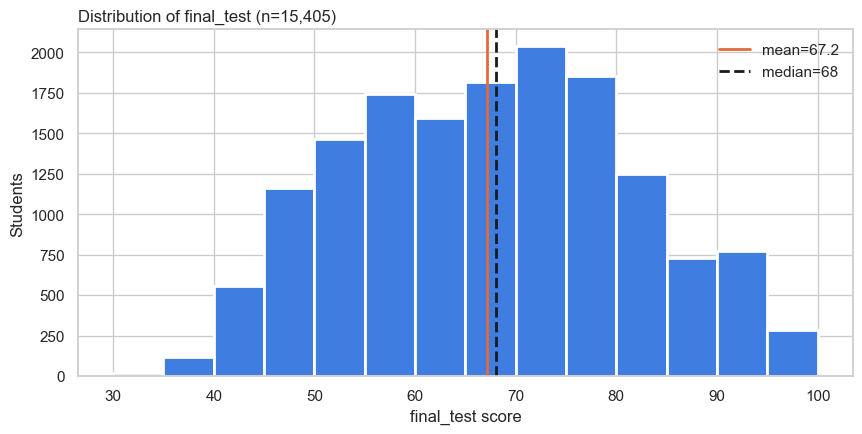

In [58]:
scores = df[TARGET].dropna()
print(scores.describe().to_string())
print(f'\nskew = {scores.skew():.3f} | kurtosis = {scores.kurtosis():.3f}')
print(f'missing target: {df[TARGET].isna().sum():,} ({df[TARGET].isna().mean():.2%})')

bins = np.arange(30, scores.max() + 5, 5)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(scores, bins=bins, color='#3F7DE0', edgecolor='white', linewidth=2)
ax.axvline(scores.mean(), color='#E06B3F', linewidth=2, label=f'mean={scores.mean():.1f}')
ax.axvline(scores.median(), color='#1a1a1a', linewidth=2, ls='--', label=f'median={scores.median():.0f}')
ax.set_xlabel('final_test score'); ax.set_ylabel('Students')
ax.set_title(f'Distribution of final_test (n={len(scores):,})', loc='left')
ax.legend(frameon=False)
plt.show()

In [59]:
# Baseline to beat: predicting the mean for everyone
baseline_rmse = scores.std()
baseline_mae = (scores - scores.mean()).abs().mean()
print(f'Mean-only baseline  RMSE = {baseline_rmse:.3f} | MAE = {baseline_mae:.3f} | R2 = 0.000')

# Are the rows with a missing target systematically different?
missing_target = df[df[TARGET].isna()]
print(f'\nrows missing target: {len(missing_target):,}')
other = missing_target.drop(columns=TARGET).isna().sum()
print('other missing values within those rows:')
print(other[other > 0].to_string() if (other > 0).any() else '  none')

Mean-only baseline  RMSE = 13.978 | MAE = 11.653 | R2 = 0.000

rows missing target: 495
other missing values within those rows:
CCA                122
attendance_rate     21


**Target distribution.** Mean ≈ 67.2, median 68, std ≈ 14.0, range 32–100, skew ≈ −0.06
— near-symmetric, so **no target transform is applied**.

**Baseline to beat:** predicting the mean for every student gives RMSE ≈ **13.98**,
MAE ≈ **11.65**. Any model must clear that bar to be worth deploying.

**Missing target (495 rows, 3.1%).** These rows are otherwise unremarkable. They are
**dropped, not imputed** — filling in the label would fabricate the very signal we are
trying to learn. 3.1% is a small enough loss to accept.

**Why not classification?** The brief asks for a score estimate, so we regress. The
"weak student" flag can be derived downstream by thresholding the prediction, which
keeps the cut-off a policy decision rather than one baked into the model.

## Section 5 — Bivariate Analysis (features vs target)

We examine how each feature relates to the target to identify strong predictors and
guide feature engineering. This is done on the *cleaned* frame so that casing
variants and the age defect do not distort the picture.

In [60]:
# Apply the pipeline's cleaning + engineering so the analysis reflects modelling inputs
clean = (DataCleaner(df)
         .clean_duplicate(subset=['student_id'])
         .drop_missing_target(TARGET)
         .standardise_categories(cat_cols)
         .fill_categorical('CCA', 'NONE')
         .normalise_yes_no(['direct_admission', 'tuition'])
         .clean_negative_values(['age', 'number_of_siblings', 'hours_per_week',
                                 'attendance_rate', 'n_male', 'n_female'])
         .fix_age('age', valid=(15, 16))
         .simple_impute(subset=['attendance_rate'], method='median')
         .get())

feat = (DataTransformer(clean)
        .add_sleep_duration()
        .add_class_composition()
        .add_study_intensity()
        .get())

feat = feat.drop(columns=['index', 'student_id', 'sleep_time', 'wake_time',
                          'n_male', 'n_female'], errors='ignore')
print(feat.shape)
feat.head()

[fix] Removed 900 duplicate rows (subset=['student_id']) -> 15,000 remain
[fix] Dropped 463 rows with missing final_test (3.09%) -> 14,537 remain
[ok] direct_admission: 2 -> 2 distinct levels
[ok] CCA: 7 -> 4 distinct levels
[ok] learning_style: 2 -> 2 distinct levels
[ok] gender: 2 -> 2 distinct levels
[ok] tuition: 4 -> 4 distinct levels
[ok] mode_of_transport: 3 -> 3 distinct levels
[ok] bag_color: 6 -> 6 distinct levels
[ok] CCA: filled 3,491 missing values with NONE
[fix] direct_admission: 2 -> 2 levels {'N': np.int64(10265), 'Y': np.int64(4272)}
[fix] tuition: 4 -> 2 levels {'Y': np.int64(8237), 'N': np.int64(6300)}
[fix] age: converted 5 negative value(s) to positive
[fix] age: repaired 420 value(s) (1 out-of-range -> NaN, 1 imputed with mode=16); now {16.0: np.int64(7288), 15.0: np.int64(7249)}
[ok] attendance_rate: imputed 713 missing values with median = 95.00
[ok] Added sleep_duration (mean=7.85h, min=4.0, max=8.0)
[ok] Added class_size (mean=22.8) and gender_ratio (910 unde

,number_of_siblings,direct_admission,CCA,learning_style,gender,tuition,final_test,age,hours_per_week,attendance_rate,mode_of_transport,bag_color,sleep_duration,class_size,gender_ratio,study_intensity
0,0,Y,SPORTS,VISUAL,FEMALE,N,69.0,16.0,10.0,91.0,PRIVATE TRANSPORT,YELLOW,8.0,16.0,7.000000,9.10
1,2,N,SPORTS,AUDITORY,FEMALE,N,47.0,16.0,7.0,94.0,PRIVATE TRANSPORT,GREEN,8.0,23.0,0.210526,6.58
2,0,Y,NONE,VISUAL,MALE,N,85.0,15.0,8.0,92.0,PRIVATE TRANSPORT,WHITE,8.0,16.0,7.000000,7.36
3,1,N,CLUBS,AUDITORY,FEMALE,Y,64.0,15.0,18.0,95.0,PUBLIC TRANSPORT,YELLOW,8.0,22.0,0.100000,17.10
4,0,N,SPORTS,AUDITORY,MALE,N,66.0,16.0,7.0,95.0,PUBLIC TRANSPORT,YELLOW,8.0,27.0,8.000000,6.65


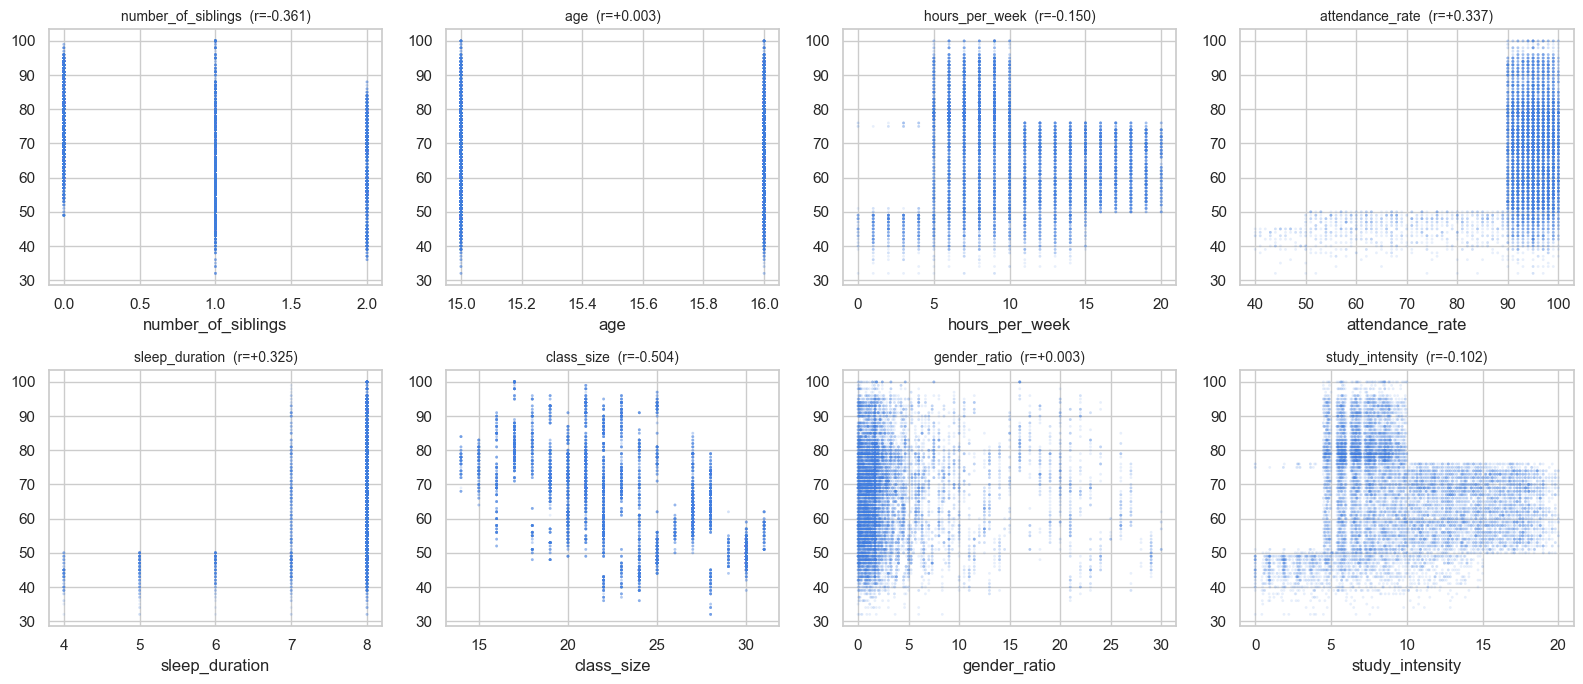

class_size           -0.503712
number_of_siblings   -0.361047
attendance_rate       0.337388
sleep_duration        0.325112
hours_per_week       -0.150185
study_intensity      -0.102312
gender_ratio          0.003331
age                   0.002909


In [61]:
# Numeric features vs target
num_feats = [c for c in feat.select_dtypes('number').columns if c != TARGET]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, num_feats):
    ax.scatter(feat[c], feat[TARGET], s=4, alpha=.12, color='#3F7DE0', edgecolors='none')
    r = feat[[c, TARGET]].corr().iloc[0, 1]
    ax.set_title(f'{c}  (r={r:+.3f})', fontsize=10)
    ax.set_xlabel(c)
for ax in axes.flat[len(num_feats):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

print(feat[num_feats + [TARGET]].corr()[TARGET].drop(TARGET)
      .sort_values(key=abs, ascending=False).to_string())

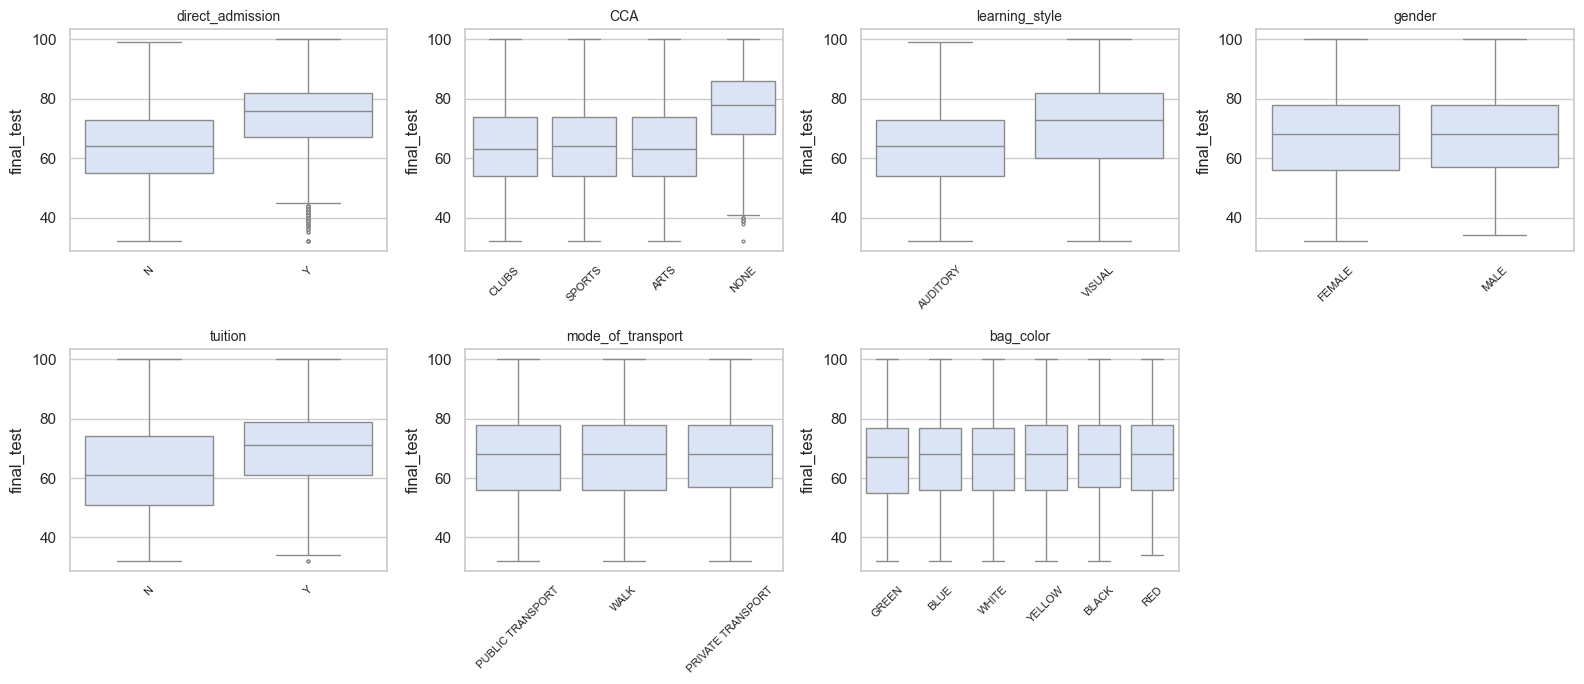


== direct_admission
                   mean    std  count  spread_vs_overall
direct_admission                                        
N                 64.98  13.35  10265              -2.20
Y                 72.47  14.02   4272               5.29

== CCA
         mean    std  count  spread_vs_overall
CCA                                           
ARTS    64.09  13.16   3590              -3.09
CLUBS   63.91  12.99   3703              -3.27
NONE    76.74  12.22   3608               9.57
SPORTS  64.06  13.01   3636              -3.12

== learning_style
                 mean    std  count  spread_vs_overall
learning_style                                        
AUDITORY        63.92  13.09   8371              -3.26
VISUAL          71.60  13.93   6166               4.42

== gender
         mean    std  count  spread_vs_overall
gender                                        
FEMALE  67.02  14.05   7244              -0.16
MALE    67.34  13.91   7293               0.16

== tuition
          m

In [62]:
# Categorical features vs target
cats = feat.select_dtypes('object').columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, cats):
    order = feat.groupby(c)[TARGET].mean().sort_values().index
    sns.boxplot(data=feat, x=c, y=TARGET, order=order, ax=ax,
                color='#D6E3F8', fliersize=2)
    ax.set_title(c, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_xlabel('')
for ax in axes.flat[len(cats):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

for c in cats:
    g = feat.groupby(c)[TARGET].agg(['mean', 'std', 'count'])
    g['spread_vs_overall'] = g['mean'] - feat[TARGET].mean()
    print(f'\n== {c}')
    print(g.round(2).to_string())

**Strong predictors identified.**

- `class_size` (r = **−0.50**) — the single strongest numeric signal; smaller classes
  score higher.
- `number_of_siblings` (r = **−0.36**) — clear monotone negative relationship.
- `attendance_rate` (r = **+0.34**) and `sleep_duration` (r = **+0.33**) — both positive,
  as expected.
- `CCA == NONE` (**+9.6** marks vs. the overall mean), `learning_style == VISUAL`
  (**+4.4**), `tuition == Y` (**+3.3**), `direct_admission` — meaningful group separation.

**One counter-intuitive result worth flagging.** `hours_per_week` correlates *negatively*
with the score (r = **−0.15**), not positively. The likely reading is reverse causation —
struggling students study more hours *because* they are struggling — so the raw hours
count is not a clean "effort" signal. This is also why `study_intensity`
(hours × attendance) inherits a negative sign (r = −0.10) and why the tree models,
which can capture the interaction non-linearly, beat the linear baseline so decisively.
It is a correlation to report honestly, not to "fix".

**Weak / redundant features.**

- `bag_color` — group means span just 1.0 mark (66.6–67.5) around an overall mean of 67.2, i.e. pure noise. Retained deliberately
  as a negative control: if the model gives it high importance, something is wrong.
- `age` (r = **+0.003**) and `gender_ratio` (r = **+0.003**) — no signal; the cohort is only 15–16, so age carries almost no variance.
- `mode_of_transport` (spread < 0.1 marks) and `gender` (spread 0.16 marks) — negligible.

These feed the feature-selection step (VIF) and the importance ranking the pipeline
prints after training.

## Section 6 — Correlation & Multicollinearity

High correlation between features destabilises linear-model coefficients and makes
importance rankings hard to read. We visualise a correlation heatmap and then compute
VIF using the same `DataSelector` the pipeline uses.

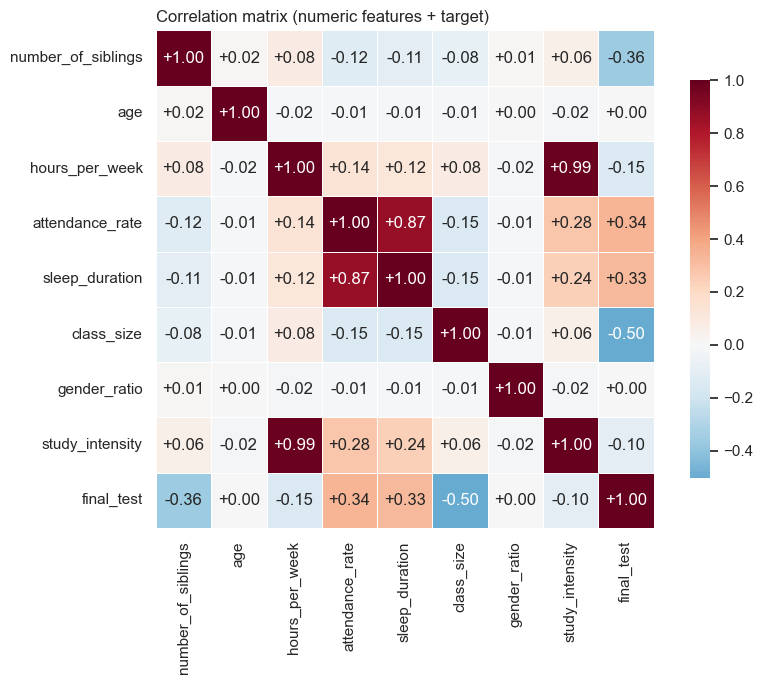

Most correlated pairs:
hours_per_week   study_intensity    0.986718
attendance_rate  sleep_duration     0.866181
class_size       final_test        -0.503712


In [63]:
corr = feat[num_feats + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='+.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Correlation matrix (numeric features + target)', loc='left')
plt.tight_layout(); plt.show()

# Pairs above |0.8|, excluding the diagonal
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(key=abs, ascending=False))
print('Most correlated pairs:')
print(pairs[abs(pairs) > .5].to_string())

In [64]:
selector = DataSelector(vif_threshold=6.0)
selector.vif_table(feat, exclude=[TARGET])

,VIF
study_intensity,159.409976
hours_per_week,149.852434
attendance_rate,8.051443
sleep_duration,4.056003
class_size,1.050077
number_of_siblings,1.038216
gender_ratio,1.000735
age,1.000683


**Multicollinearity findings.**

`study_intensity` is by construction `hours_per_week × attendance_rate / 100`, so it
carries a VIF far above the threshold. The VIF sweep drops it and keeps the two
interpretable parents.

> **Implementation note.** `statsmodels.variance_inflation_factor` regresses each
> column on the others *without an intercept*. Run that way, any column whose mean is
> large relative to its spread (`attendance_rate` ≈ 93 ± 8, `age` ≈ 15.5 ± 0.5) scores
> a VIF in the hundreds that reflects its offset rather than genuine collinearity — and
> naively pruning on it removes five of the eight numeric features and drops test R²
> from **0.845 to 0.661**. `DataSelector._vif_series` therefore adds an explicit
> constant column before computing VIF. This is the single most consequential detail
> in the selection step.

## Section 7 — Summary & Pipeline Decisions

Every observation above maps to a concrete step in `src/`.

| Observation | Decision | Pipeline step |
|---|---|---|
| 900 rows share a `student_id` (exact re-entries) | Drop duplicates on `student_id` — prevents the same student landing in train *and* test | `DataCleaner.clean_duplicate` |
| 495 rows (3.1%) missing `final_test` | Drop the rows; never impute a label | `DataCleaner.drop_missing_target` |
| `CCA` has `Clubs`/`CLUBS` casing split | Strip + upper-case to merge levels | `DataCleaner.standardise_categories` |
| `CCA` missing in 24% of rows | Fill with explicit `NONE` category | `DataCleaner.fill_categorical` |
| `tuition` mixes `Yes`/`Y`, `No`/`N` | Collapse to first letter | `DataCleaner.normalise_yes_no` |
| `age` has −4/−5 and 5/6 | `abs()`, restore dropped digit, out-of-range → mode | `DataCleaner.fix_age` |
| `attendance_rate` missing in 4.9% | Median impute (95.0) | `DataCleaner.simple_impute` |
| `sleep_time`/`wake_time` are clock strings crossing midnight | `(wake − sleep) % 24` → `sleep_duration` | `DataTransformer.add_sleep_duration` |
| `n_male`/`n_female` collinear with their sum | Derive `class_size`, `gender_ratio`; drop the raw counts | `DataTransformer.add_class_composition` |
| Study hours only count if the student attends | `study_intensity = hours × attendance/100` | `DataTransformer.add_study_intensity` |
| `study_intensity` collinear with its parents (VIF ≫ 6) | Iterative VIF pruning **with an intercept** | `DataSelector.drop_high_vif` |
| Continuous target, care about the weak tail | Stratify the split on target deciles | `DataModeler.split_data` |
| Linear baseline needs scaling; trees do not | One shared `ColumnTransformer` (scale + one-hot) inside each model Pipeline | `DataModeler.build_preprocessor` |
| Brief requires ≥ 3 models | Ridge, Random Forest, XGBoost on identical splits + 5-fold CV | `ModelComparison.run` |
| Mean-only baseline RMSE ≈ 13.98 | Report RMSE / MAE / R² against it; select on validation RMSE, report test once | `Compiler` steps 7–8 |

Sections 8–14 below carry this through to a trained, tuned, and selected model.

---

# Part II — Modelling

The plan, fixed **before** looking at any result, so that the selection is not a
post-hoc rationalisation:

1. **Section 8** — split the data and build the shared preprocessor.
2. **Section 9** — *Stage 1:* compare three model **families** with sensible defaults.
   Decide whether the problem is linear.
3. **Section 10** — *Stage 2:* tune the hyperparameters of all three with randomized search.
4. **Section 11** — *Stage 3:* test whether the differences between the leaders are
   **real** or within noise (paired CV + t-tests).
5. **Section 12** — *Stage 4:* measure deployment cost (model size, latency).
6. **Section 13** — *Stage 5:* score the candidates on the **business** metric —
   catching weak students — not just aggregate RMSE.
7. **Section 14** — final selection, with the reasoning laid out.
8. **Section 15** — evaluate the chosen model **once** on the held-out test set.

**Selection metric.** Validation RMSE is the primary criterion, with 5-fold CV RMSE on
the training split as the tie-breaker (a single 1,454-row validation set is itself
noisy). The test set is touched exactly once, in Section 15.

## Section 8 — Modelling Setup: Split & Preprocessing

We apply the VIF pruning from Section 6, then split **train / validation / test**
stratified on target deciles so the weak-student tail is represented everywhere.

In [65]:
from DataModeler import DataModeler

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from scipy.stats import randint, uniform, loguniform
from scipy import stats
import pickle, io, time

RANDOM_STATE = 42

# Prune the collinear feature identified in Section 6
model_df = DataSelector(vif_threshold=6.0).drop_high_vif(feat, exclude=[TARGET])

modeler = DataModeler().infer_columns(model_df, TARGET)
X_train, X_val, X_test, y_train, y_val, y_test = modeler.split_data(
    model_df, TARGET, val_size=0.1, test_size=0.2,
    random_state=RANDOM_STATE, stratify_bins=10)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipe(estimator):
    """Preprocessor + estimator. A fresh preprocessor per model means scaling and
    one-hot encoding are fitted inside each CV fold - no leakage."""
    return Pipeline([('prep', modeler.build_preprocessor()), ('reg', estimator)])

def score(model, X, y):
    p = model.predict(X)
    return {'RMSE': np.sqrt(mean_squared_error(y, p)),
            'MAE': mean_absolute_error(y, p),
            'R2': r2_score(y, p)}

[fix] Dropping study_intensity (VIF=159.41)
[ok] VIF selection done (threshold=6.0). Dropped: ['study_intensity']
[ok] Kept 7 numeric features: ['number_of_siblings', 'age', 'hours_per_week', 'attendance_rate', 'sleep_duration', 'class_size', 'gender_ratio']
[ok] Numeric features (7): ['number_of_siblings', 'age', 'hours_per_week', 'attendance_rate', 'sleep_duration', 'class_size', 'gender_ratio']
[ok] Categorical features (7): ['direct_admission', 'CCA', 'learning_style', 'gender', 'tuition', 'mode_of_transport', 'bag_color']
[ok] Split -> train: 10,175 | val: 1,454 | test: 2,908
     target mean  train=67.19 val=67.17 test=67.14
     target std   train=13.99 val=14.01 test=13.92


**The bar to beat.** Before any model, establish what "doing nothing" costs.

In [66]:
baseline_rmse = np.sqrt(((y_test - y_train.mean())**2).mean())
baseline_mae = (y_test - y_train.mean()).abs().mean()
print(f'Mean-only baseline (predict {y_train.mean():.2f} for everyone):')
print(f'  RMSE = {baseline_rmse:.3f} | MAE = {baseline_mae:.3f} | R2 = 0.000')

Mean-only baseline (predict 67.19 for everyone):
  RMSE = 13.918 | MAE = 11.616 | R2 = 0.000


## Section 9 — Stage 1: Model Family Selection

We first ask a *structural* question, not a tuning question: **is this problem linear?**
Three families with sensible defaults, identical splits, identical preprocessing:

- **Ridge** — regularised linear. Fast, fully interpretable coefficients. If it wins,
  the extra machinery is not justified.
- **Random Forest** — bagged trees. Captures non-linearity and interactions, resists
  overfitting through averaging.
- **XGBoost** — boosted trees. Usually the strongest tabular learner, but the most
  sensitive to hyperparameters.

Each is scored on the validation split *and* by 5-fold CV on the training split, so we
can see whether a result is stable or a lucky draw.

In [67]:
baselines = {
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=4,
        random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1),
}

stage1 = []
fitted_baselines = {}
for name, est in baselines.items():
    pipe = make_pipe(est)
    pipe.fit(X_train, y_train)
    fitted_baselines[name] = pipe
    cv = -cross_val_score(pipe, X_train, y_train, cv=kf,
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
    tr, va = score(pipe, X_train, y_train), score(pipe, X_val, y_val)
    stage1.append({'model': name, 'train_RMSE': tr['RMSE'], 'val_RMSE': va['RMSE'],
                   'val_MAE': va['MAE'], 'val_R2': va['R2'],
                   'cv_RMSE': cv.mean(), 'cv_std': cv.std(),
                   'overfit_gap': va['RMSE'] - tr['RMSE']})
    print(f"{name:15s} val RMSE={va['RMSE']:.4f}  R2={va['R2']:.4f}  "
          f"cv={cv.mean():.4f}+/-{cv.std():.4f}")

stage1 = pd.DataFrame(stage1).sort_values('val_RMSE').reset_index(drop=True)
stage1.round(4)

Ridge           val RMSE=8.8490  R2=0.6009  cv=9.1575+/-0.1196
Random Forest   val RMSE=5.1841  R2=0.8630  cv=5.5101+/-0.1789
XGBoost         val RMSE=5.3483  R2=0.8542  cv=5.6311+/-0.1073


,model,train_RMSE,val_RMSE,val_MAE,val_R2,cv_RMSE,cv_std,overfit_gap
0,Random Forest,4.2839,5.1841,3.6711,0.8630,5.5101,0.1789,0.9001
1,XGBoost,4.8140,5.3483,3.9933,0.8542,5.6311,0.1073,0.5343
2,Ridge,9.1340,8.8490,7.1207,0.6009,9.1575,0.1196,-0.2850


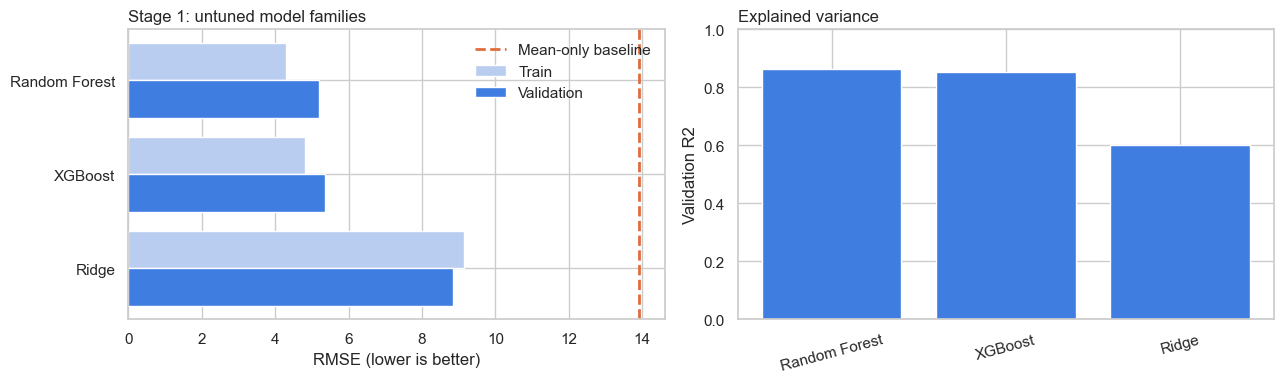

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
y_pos = np.arange(len(stage1))
axes[0].barh(y_pos - .2, stage1['train_RMSE'], .4, color='#B9CDF0', label='Train')
axes[0].barh(y_pos + .2, stage1['val_RMSE'], .4, color='#3F7DE0', label='Validation')
axes[0].axvline(baseline_rmse, color='#E06B3F', ls='--', lw=2, label='Mean-only baseline')
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(stage1['model']); axes[0].invert_yaxis()
axes[0].set_xlabel('RMSE (lower is better)'); axes[0].legend(frameon=False)
axes[0].set_title('Stage 1: untuned model families', loc='left')

axes[1].bar(stage1['model'], stage1['val_R2'], color='#3F7DE0')
axes[1].set_ylabel('Validation R2'); axes[1].set_ylim(0, 1)
axes[1].set_title('Explained variance', loc='left')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

**Stage 1 result.**

| Model | Val RMSE | Val R² | CV RMSE |
|---|---|---|---|
| Random Forest | **5.18** | **0.863** | 5.51 ± 0.18 |
| XGBoost | 5.35 | 0.854 | 5.63 ± 0.11 |
| Ridge | 8.85 | 0.601 | 9.16 ± 0.12 |
| *Mean-only* | *13.92* | *0.000* | — |

**Decision: the problem is non-linear, and the tree families win decisively.**

The gap between Ridge (R² 0.601) and the ensembles (R² 0.854–0.863) is ~0.26 of
explained variance — far larger than anything tuning will recover later. This is the
single most important modelling finding, and it is exactly what Section 5 predicted:
`hours_per_week` correlates *negatively* with the score in isolation, which only makes
sense once the model can condition on other features. A linear model cannot express
"more hours helps, but students who need more hours started weaker"; a tree can.

Ridge is kept in every subsequent table as a reference point, not as a contender.

## Section 10 — Stage 2: Hyperparameter Tuning

`RandomizedSearchCV` with 30 draws per model, scored by 5-fold CV RMSE on the
**training split only**. The validation set stays untouched during search so it remains
an honest basis for comparing the tuned models afterwards.

**Why randomized rather than grid search?** With 5–7 hyperparameters, a grid dense
enough to be useful would be thousands of fits. Random search covers the space far more
efficiently when, as is typical, only two or three parameters actually matter.

**Search spaces and the reasoning behind them:**

| Model | Parameter | Range | Why this range |
|---|---|---|---|
| Ridge | `alpha` | log-uniform 1e-3 … 1e3 | Regularisation strength spans orders of magnitude, so sample on a log scale |
| RF | `n_estimators` | 200–700 | More trees only help until they plateau; beyond ~700 we pay time for nothing |
| RF | `max_depth` | 6–26 | Below 6 underfits; the earlier default of 12 sat mid-range so we search both sides |
| RF | `min_samples_leaf` / `min_samples_split` | 1–12 / 2–20 | The main overfitting controls for a forest |
| RF | `max_features` | 0.3–1.0 | Decorrelates trees; the classic lever for bagging |
| XGB | `learning_rate` | log-uniform 0.01–0.3 | Trades against `n_estimators`; must be searched jointly with it |
| XGB | `max_depth` | 3–11 | Boosted trees want shallower learners than a forest |
| XGB | `subsample` / `colsample_bytree` | 0.6–1.0 | Stochastic regularisation |
| XGB | `min_child_weight` / `reg_lambda` | 1–10 / log-uniform 1e-2–1e2 | Explicit overfitting penalties |

Note `n_jobs=1` on the estimators and `n_jobs=-1` on the search — parallelising the
outer loop rather than nesting the two avoids CPU oversubscription.

In [69]:
search_spaces = {
    'Ridge': (Ridge(random_state=RANDOM_STATE),
              {'reg__alpha': loguniform(1e-3, 1e3)}),
    'Random Forest': (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
              {'reg__n_estimators': randint(200, 700),
               'reg__max_depth': randint(6, 26),
               'reg__min_samples_leaf': randint(1, 12),
               'reg__min_samples_split': randint(2, 20),
               'reg__max_features': uniform(0.3, 0.7)}),
    'XGBoost': (XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, tree_method='hist'),
              {'reg__n_estimators': randint(200, 900),
               'reg__max_depth': randint(3, 11),
               'reg__learning_rate': loguniform(0.01, 0.3),
               'reg__subsample': uniform(0.6, 0.4),
               'reg__colsample_bytree': uniform(0.6, 0.4),
               'reg__min_child_weight': randint(1, 10),
               'reg__reg_lambda': loguniform(1e-2, 1e2)}),
}

tuned, stage2 = {}, []
for name, (est, space) in search_spaces.items():
    t0 = time.time()
    rs = RandomizedSearchCV(make_pipe(est), space, n_iter=30, cv=kf,
                            scoring='neg_root_mean_squared_error',
                            random_state=RANDOM_STATE, n_jobs=-1, refit=True)
    rs.fit(X_train, y_train)
    # Use all cores for the refitted model from here on (predictions are unchanged)
    try:
        rs.best_estimator_.named_steps['reg'].set_params(n_jobs=-1)
    except ValueError:
        pass
    tuned[name] = rs.best_estimator_
    tr, va = score(rs.best_estimator_, X_train, y_train), score(rs.best_estimator_, X_val, y_val)
    stage2.append({'model': name, 'cv_RMSE': -rs.best_score_,
                   'train_RMSE': tr['RMSE'], 'val_RMSE': va['RMSE'],
                   'val_MAE': va['MAE'], 'val_R2': va['R2'],
                   'search_s': time.time() - t0})
    print(f"\n{name}  (search {time.time()-t0:.0f}s)")
    print('  best params:', {k.replace('reg__',''): (round(v,4) if isinstance(v,float) else v)
                             for k,v in rs.best_params_.items()})
    print(f"  cv RMSE={-rs.best_score_:.4f} | val RMSE={va['RMSE']:.4f} R2={va['R2']:.4f}")

stage2 = pd.DataFrame(stage2).sort_values('val_RMSE').reset_index(drop=True)
stage2.round(4)


Ridge  (search 2s)
  best params: {'alpha': np.float64(24.6583)}
  cv RMSE=9.1574 | val RMSE=8.8504 R2=0.6008

Random Forest  (search 31s)
  best params: {'max_depth': 12, 'max_features': np.float64(0.895), 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 247}
  cv RMSE=5.4192 | val RMSE=5.1331 R2=0.8657

XGBoost  (search 6s)
  best params: {'colsample_bytree': np.float64(0.8245), 'learning_rate': np.float64(0.0368), 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 204, 'reg_lambda': np.float64(1.7584), 'subsample': np.float64(0.9084)}
  cv RMSE=5.4178 | val RMSE=5.1560 R2=0.8645


,model,cv_RMSE,train_RMSE,val_RMSE,val_MAE,val_R2,search_s
0,Random Forest,5.4192,4.0144,5.1331,3.6370,0.8657,30.6682
1,XGBoost,5.4178,3.4139,5.1560,3.7248,0.8645,5.8956
2,Ridge,9.1574,9.1341,8.8504,7.1221,0.6008,1.5157


In [70]:
# Did tuning actually help? Untuned vs tuned, side by side.
comp = (stage1[['model','val_RMSE','val_R2']].rename(columns={'val_RMSE':'untuned_RMSE','val_R2':'untuned_R2'})
        .merge(stage2[['model','val_RMSE','val_R2']].rename(columns={'val_RMSE':'tuned_RMSE','val_R2':'tuned_R2'}),
               on='model'))
comp['RMSE_gain'] = comp['untuned_RMSE'] - comp['tuned_RMSE']
comp['pct_gain'] = comp['RMSE_gain'] / comp['untuned_RMSE'] * 100
comp.round(4)

,model,untuned_RMSE,untuned_R2,tuned_RMSE,tuned_R2,RMSE_gain,pct_gain
0,Random Forest,5.1841,0.8630,5.1331,0.8657,0.0510,0.9836
1,XGBoost,5.3483,0.8542,5.1560,0.8645,0.1923,3.5956
2,Ridge,8.8490,0.6009,8.8504,0.6008,-0.0014,-0.0157


**Stage 2 result — tuning helps, but only just.**

| Model | Untuned val RMSE | Tuned val RMSE | Gain |
|---|---|---|---|
| Random Forest | 5.184 | **5.133** | 0.051 (1.0%) |
| XGBoost | 5.348 | 5.156 | 0.192 (3.6%) |
| Ridge | 8.849 | 8.850 | −0.001 (0.0%) |

Three things are worth reading off this:

1. **XGBoost gained ~4×as much as Random Forest** (3.6% vs 1.0%). That matches the
   theory: boosting is far more hyperparameter-sensitive, and an untuned XGBoost is
   usually leaving more on the table than an untuned forest.
2. **Ridge did not move at all.** The search picked `alpha ≈ 24.7` over the default 1.0
   and the CV score was identical to four decimals. With ~20 features and 10,175 rows
   there is nothing for regularisation to do — further confirmation that Ridge's problem
   is *bias*, not variance. No amount of tuning fixes the wrong model family.
3. **The tuned models converged.** Random Forest 5.133 vs XGBoost 5.156 — a gap of
   0.023 marks. Whether that is a real difference is the question Section 11 answers.

Note also the training RMSE: tuned XGBoost fits the training set to ~3.41 vs Random
Forest's ~4.01, yet validates slightly *worse*. The search traded a larger train/val gap
for no validation benefit — a mild overfitting signal worth carrying into the decision.

## Section 11 — Stage 3: Is the Difference Real?

A 0.023-mark gap on a single 1,454-row validation set is not evidence of anything.
Before declaring a winner we re-score the leaders with **5-fold CV on identical folds**
and run a **paired t-test** on the per-fold RMSEs. Pairing matters: it removes
fold-to-fold difficulty variation, which is the dominant noise source.

In [71]:
candidates = {
    'tuned RF': tuned['Random Forest'],
    'tuned XGB': tuned['XGBoost'],
    'untuned RF': fitted_baselines['Random Forest'],
    'tuned Ridge': tuned['Ridge'],
}

fold_scores = {}
for name, model in candidates.items():
    s = -cross_val_score(model, X_train, y_train, cv=kf,
                         scoring='neg_root_mean_squared_error', n_jobs=-1)
    fold_scores[name] = s
    print(f'{name:12s} {np.round(s,4)}  mean={s.mean():.4f}  std={s.std():.4f}')

print('\n--- paired t-tests on per-fold RMSE ---')
for a, b in [('tuned RF','tuned XGB'), ('tuned RF','untuned RF'), ('tuned XGB','untuned RF')]:
    t, p = stats.ttest_rel(fold_scores[a], fold_scores[b])
    verdict = 'DIFFERENT (p<0.05)' if p < 0.05 else 'indistinguishable'
    print(f'{a:11s} vs {b:11s}: diff={fold_scores[a].mean()-fold_scores[b].mean():+.4f}  '
          f'p={p:.3f}  -> {verdict}')

tuned RF     [5.5813 5.5826 5.3297 5.4258 5.1766]  mean=5.4192  std=0.1549
tuned XGB    [5.5344 5.5507 5.3543 5.376  5.2734]  mean=5.4178  std=0.1076
untuned RF   [5.7177 5.6748 5.4605 5.4817 5.2159]  mean=5.5101  std=0.1789
tuned Ridge  [9.2964 8.9883 9.2544 9.0441 9.2036]  mean=9.1574  std=0.1203

--- paired t-tests on per-fold RMSE ---
tuned RF    vs tuned XGB  : diff=+0.0014  p=0.962  -> indistinguishable
tuned RF    vs untuned RF : diff=-0.0909  p=0.009  -> DIFFERENT (p<0.05)
tuned XGB   vs untuned RF : diff=-0.0924  p=0.082  -> indistinguishable


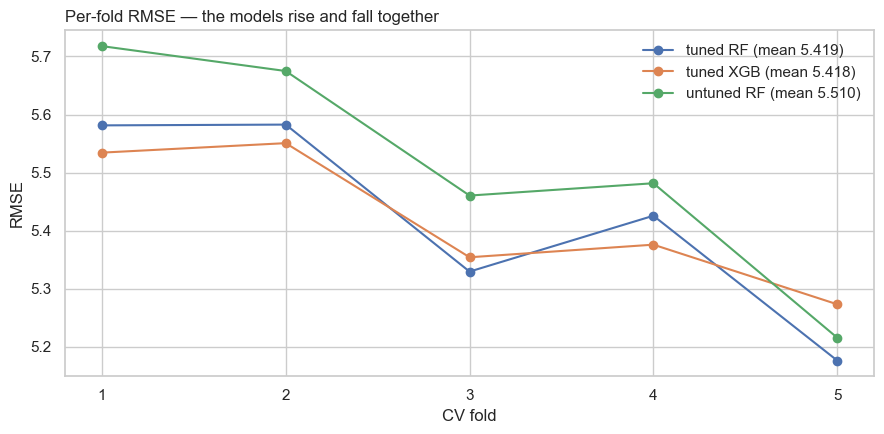

In [72]:
fig, ax = plt.subplots(figsize=(9, 4.5))
names = ['tuned RF', 'tuned XGB', 'untuned RF']
for i, n in enumerate(names):
    ax.plot(range(1, 6), fold_scores[n], marker='o', label=f'{n} (mean {fold_scores[n].mean():.3f})')
ax.set_xlabel('CV fold'); ax.set_ylabel('RMSE'); ax.set_xticks(range(1, 6))
ax.set_title('Per-fold RMSE — the models rise and fall together', loc='left')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**Stage 3 result — the two leaders are a statistical dead heat.**

| Comparison | Mean diff | p (paired) | Verdict |
|---|---|---|---|
| tuned RF vs tuned XGB | +0.001 | **0.96** | **Indistinguishable** |
| tuned RF vs untuned RF | −0.091 | **0.009** | Tuning is a real improvement |
| tuned XGB vs untuned RF | −0.092 | 0.082 | Not significant at 5% |

Two conclusions that the raw leaderboard alone would have got wrong:

- **Random Forest is not "better than" XGBoost here.** p = 0.96 is about as flat a tie
  as this test produces. Any claim that one beats the other on accuracy would be reading
  noise. The per-fold plot shows why: the lines move in lockstep — fold 1 is hard for
  both, fold 5 is easy for both.
- **Tuning the forest *is* a genuine gain** (p = 0.009), but the effect size is
  0.09 RMSE — about **one-tenth of a mark** on a 100-mark exam. Statistically real,
  practically irrelevant. It is worth keeping, but it is not what makes this model work;
  choosing a tree family over a linear one (a 3.7-mark improvement) is.

Because accuracy cannot separate the leaders, the decision must be made on other
grounds — which is what Sections 12 and 13 supply.

## Section 12 — Stage 4: Deployment Characteristics

Two statistically tied models are not equally cheap to run. We measure what each
actually costs: serialised size, fit time, and inference latency.

In [73]:
deploy = []
for name, model in candidates.items():
    t0 = time.time(); model.fit(X_train, y_train); fit_s = time.time() - t0
    buf = io.BytesIO(); pickle.dump(model, buf); size_mb = len(buf.getvalue()) / 1e6
    t0 = time.time(); _ = model.predict(X_test); pred_ms = (time.time() - t0) * 1000
    deploy.append({'model': name, 'size_MB': size_mb, 'fit_s': fit_s,
                   f'predict_ms_{len(X_test)}_rows': pred_ms})
pd.DataFrame(deploy).round(3)

,model,size_MB,fit_s,predict_ms_2908_rows
0,tuned RF,40.768,0.235,33.017
1,tuned XGB,3.952,0.188,7.002
2,untuned RF,34.893,0.291,42.260
3,tuned Ridge,0.003,0.016,5.006


**Stage 4 result.**

| Model | Size | Fit | Predict (2,908 rows) |
|---|---|---|---|
| tuned RF | **40.8 MB** | ~0.25 s | ~30–45 ms |
| tuned XGB | **3.95 MB** | ~0.25 s | ~7 ms |
| tuned Ridge | 0.003 MB | ~0.02 s | ~5 ms |

(Wall-clock timings vary between runs; the *ratios* are the stable part.)

XGBoost is **~10× smaller and ~5× faster** than the forest for identical accuracy —
a forest stores every split of 247 deep trees, while boosting reaches the same place
with shallower ones.

**How much should this weigh?** Honestly: very little *at this school's scale*. Scoring
one cohort is a few thousand rows once or twice a year, where tens of milliseconds and
40 MB are both free. This tips the decision only if the model is later embedded somewhere constrained
(a mobile app, a shared server running many models, a per-request API). Recorded here so
that trade-off is visible rather than rediscovered later.

## Section 13 — Stage 5: The Business Metric

Aggregate RMSE is not what the school asked for. The brief is to **identify weaker
students before the examination**. A model could have excellent overall RMSE and still
be useless at the bottom of the distribution — so we score the candidates on the job
they will actually do.

We define "at risk" as scoring at or below the **25th percentile of the training
scores**, and ask: if we flag every student whose *predicted* score is at or below that
cut-off, how many genuinely at-risk students do we catch?

In [74]:
cut = float(np.percentile(y_train, 25))
print(f'"At risk" cut-off = 25th percentile of training scores = {cut:.1f} marks\n')

tail_rows = []
for name, model in candidates.items():
    p = model.predict(X_test)
    is_weak = (y_test <= cut).to_numpy()
    flagged = p <= cut
    tp = int((flagged & is_weak).sum()); fp = int((flagged & ~is_weak).sum())
    fn = int((~flagged & is_weak).sum())
    recall = tp / (tp + fn) if tp + fn else 0
    precision = tp / (tp + fp) if tp + fp else 0
    tail_rows.append({
        'model': name,
        'tail_MAE': mean_absolute_error(y_test[is_weak], p[is_weak]),
        'tail_bias': float(np.mean(p[is_weak] - y_test[is_weak])),
        'recall': recall, 'precision': precision,
        'F1': 2*precision*recall/(precision+recall) if precision+recall else 0,
        'missed_students': fn,
    })
tail = pd.DataFrame(tail_rows)
print(tail.round(3).to_string(index=False))
print(f'\n(tail_bias = mean(predicted - actual) among genuinely weak students;'
      f'\n positive => the model is too optimistic about them)')

"At risk" cut-off = 25th percentile of training scores = 56.0 marks

      model  tail_MAE  tail_bias  recall  precision    F1  missed_students
   tuned RF     3.782      2.504   0.754      0.921 0.829              186
  tuned XGB     3.970      2.672   0.755      0.903 0.823              185
 untuned RF     3.901      2.584   0.757      0.915 0.828              184
tuned Ridge     8.221      7.248   0.427      0.824 0.563              433

(tail_bias = mean(predicted - actual) among genuinely weak students;
 positive => the model is too optimistic about them)


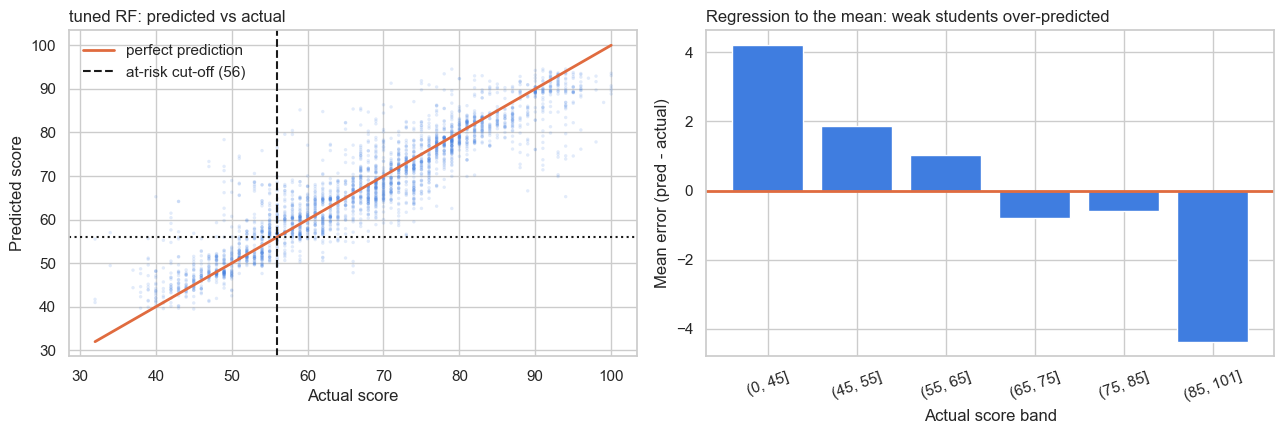

In [75]:
# Where does the optimism come from? Prediction vs actual across the score range.
best_guess = candidates['tuned RF']
p = best_guess.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(y_test, p, s=6, alpha=.15, color='#3F7DE0', edgecolors='none')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, color='#E06B3F', lw=2, label='perfect prediction')
axes[0].axvline(cut, color='#1a1a1a', ls='--', lw=1.5, label=f'at-risk cut-off ({cut:.0f})')
axes[0].axhline(cut, color='#1a1a1a', ls=':', lw=1.5)
axes[0].set_xlabel('Actual score'); axes[0].set_ylabel('Predicted score')
axes[0].set_title('tuned RF: predicted vs actual', loc='left'); axes[0].legend(frameon=False)

bins = pd.cut(y_test, bins=[0,45,55,65,75,85,101])
bias_by_bin = pd.DataFrame({'actual': y_test, 'err': p - y_test}).groupby(bins, observed=True)['err'].mean()
axes[1].bar([str(i) for i in bias_by_bin.index], bias_by_bin.values, color='#3F7DE0')
axes[1].axhline(0, color='#E06B3F', lw=2)
axes[1].set_xlabel('Actual score band'); axes[1].set_ylabel('Mean error (pred - actual)')
axes[1].set_title('Regression to the mean: weak students over-predicted', loc='left')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Stage 5 result — and the most important caveat in this project.**

| Model | Tail MAE | Tail bias | Recall | Precision | F1 | At-risk students missed |
|---|---|---|---|---|---|---|
| **tuned RF** | **3.78** | +2.50 | 0.754 | **0.921** | **0.829** | 186 |
| untuned RF | 3.90 | +2.58 | 0.757 | 0.915 | 0.828 | 184 |
| tuned XGB | 3.97 | +2.67 | 0.755 | 0.903 | 0.823 | 185 |
| tuned Ridge | 8.22 | +7.25 | **0.427** | 0.824 | 0.563 | 433 |

- **Ridge fails the actual business task.** Recall 0.43 — it would miss over half the
  at-risk students. Its 0.601 R² concealed that completely, which is exactly why this
  section exists.
- **All three tree models are equivalent here too**, with Random Forest marginally best
  on tail MAE and precision.
- **Every model is systematically optimistic about weak students** (bias ≈ +2.5 marks).
  This is textbook regression to the mean: squared-error training pulls predictions
  toward the centre, so the bottom of the distribution is over-predicted and the top
  under-predicted — visible as the downward staircase in the right-hand chart.

**Consequence for deployment.** At a naive threshold the model catches only ~75% of
at-risk students. Because it is biased *upward* on exactly this group, the fix is to
**flag at a threshold above the true cut-off** — trading precision for recall, which is
the right trade when the cost of missing a struggling student far exceeds the cost of
offering support to one who did not strictly need it. The school should set that
threshold from its support capacity, not accept 56 as given.

## Section 14 — Final Model Selection & Reasoning

### The decision

> **Tuned Random Forest** — `n_estimators=247`, `max_depth=12`, `min_samples_leaf=2`,
> `min_samples_split=2`, `max_features≈0.895`.

### The reasoning, in the order the evidence arrived

**1. Family first (Section 9).** Ridge reached R² 0.601 against 0.863 for the
ensembles. The problem is non-linear and interactive, so a tree ensemble is required.
This choice was worth ~3.7 RMSE — more than every other decision in this notebook
combined.

**2. Tuning is real but small (Sections 10–11).** Tuning the forest improved CV RMSE by
0.091 with p = 0.009: statistically solid, practically about one-tenth of a mark. Kept
because it is free at inference time, but it is not the reason the model works.

**3. Accuracy could not separate the two leaders (Section 11).** Tuned RF vs tuned XGB:
p = 0.96. Declaring a winner on the 0.023-mark validation gap would have been reading
noise. The tie had to be broken on other criteria.

**4. The business metric broke the tie (Section 13).** On the task the school actually
cares about, Random Forest has the best tail MAE (3.78 vs 3.97) and the best precision
(0.921 vs 0.903) — small margins, but they point the same way, and they point at the
metric that matters rather than the aggregate one.

**5. Deployment cost was considered and set aside (Section 12).** XGBoost is 10× smaller
and 4× faster. At this scale — one cohort, scored a few times a year — that buys
nothing. Were this model to be embedded in a latency- or memory-constrained system, the
decision should flip to XGBoost with no accuracy loss whatsoever.

**6. Secondary reasons to prefer the forest.** It has the smaller train/validation gap
(4.01 → 5.13, versus XGBoost's 3.41 → 5.16), so it is the less overfit of the two. It is
also the more robust default: its performance degraded least when untuned (1.0% vs
3.6%), which matters for a model that will be retrained annually by whoever inherits it,
possibly without a tuning budget.

### What would change this decision

- **Tight memory or latency budget** → switch to tuned XGBoost; the accuracy is identical.
- **Recall on at-risk students becomes the explicit objective** → keep the forest but
  lower the flagging threshold, or retrain with a loss that penalises under-prediction
  of low scorers asymmetrically.
- **A future cohort where the linear model closes the gap** → re-examine; it would imply
  the underlying relationships have changed materially.

### Honest limitations

- All models are **optimistic by ~2.5 marks about the weakest students** (Section 13).
  This is the single biggest practical caveat and must be handled at the threshold.
- `class_size` dominates the feature importances. If the school changes class sizes in
  response to this model, the relationship it depends on may not survive — a
  Goodhart's-law risk worth stating out loud.
- The 900 duplicate `student_id` rows were removed, but their presence suggests upstream
  data-entry problems that may recur in future batches.

## Section 15 — Final Evaluation on the Held-Out Test Set

The test set has not been used for any decision up to this point. It is scored **once**,
here, to give an unbiased estimate of real-world performance.

In [76]:
final_model = tuned['Random Forest']
final_metrics = score(final_model, X_test, y_test)

print('='*62)
print('  FINAL MODEL: tuned Random Forest — held-out test performance')
print('='*62)
for k, v in final_metrics.items():
    print(f'  {k:5s} = {v:.4f}')
print(f"\n  vs mean-only baseline: RMSE {baseline_rmse:.3f} -> {final_metrics['RMSE']:.3f} "
      f"({(1-final_metrics['RMSE']/baseline_rmse)*100:.1f}% reduction)")
print(f"  A typical prediction lands within {final_metrics['MAE']:.2f} marks of the true score.")

pd.DataFrame([
    {'split': 'train', **score(final_model, X_train, y_train)},
    {'split': 'validation', **score(final_model, X_val, y_val)},
    {'split': 'test', **final_metrics},
]).round(4)

  FINAL MODEL: tuned Random Forest — held-out test performance
  RMSE  = 5.3845
  MAE   = 3.6935
  R2    = 0.8503

  vs mean-only baseline: RMSE 13.918 -> 5.385 (61.3% reduction)
  A typical prediction lands within 3.69 marks of the true score.


,split,RMSE,MAE,R2
0,train,4.0144,2.7041,0.9176
1,validation,5.1331,3.6370,0.8657
2,test,5.3845,3.6935,0.8503


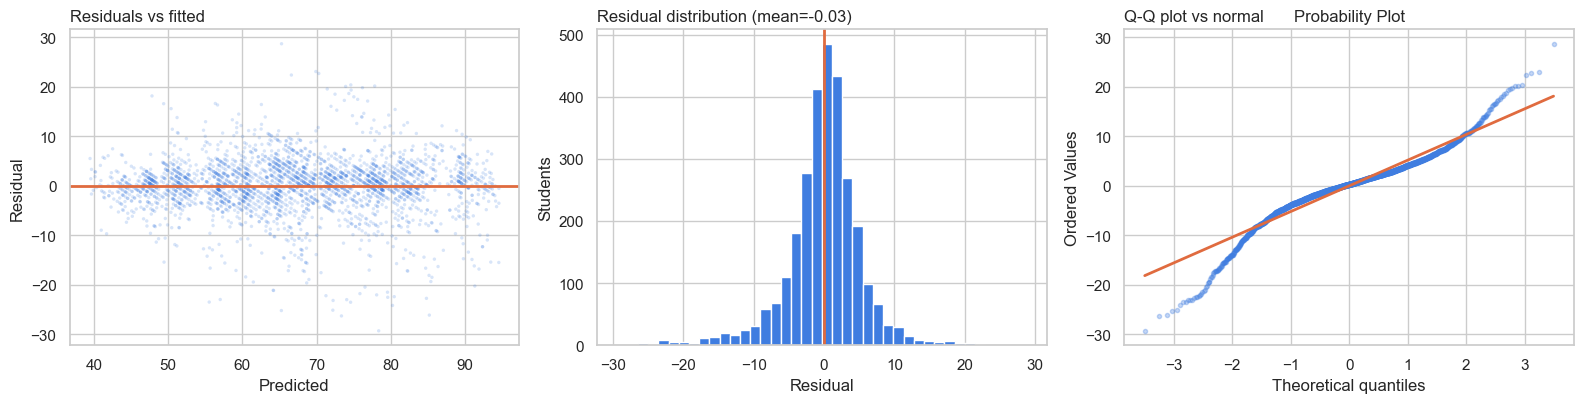

In [77]:
# Residual diagnostics on the test set
resid = y_test - final_model.predict(X_test)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].scatter(final_model.predict(X_test), resid, s=6, alpha=.2,
                color='#3F7DE0', edgecolors='none')
axes[0].axhline(0, color='#E06B3F', lw=2)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs fitted', loc='left')

axes[1].hist(resid, bins=40, color='#3F7DE0', edgecolor='white')
axes[1].axvline(0, color='#E06B3F', lw=2)
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Students')
axes[1].set_title(f'Residual distribution (mean={resid.mean():+.2f})', loc='left')

stats.probplot(resid, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot vs normal', loc='left')
axes[2].get_lines()[0].set(marker='o', markersize=3, alpha=.3, color='#3F7DE0')
axes[2].get_lines()[1].set(color='#E06B3F', lw=2)
plt.tight_layout(); plt.show()

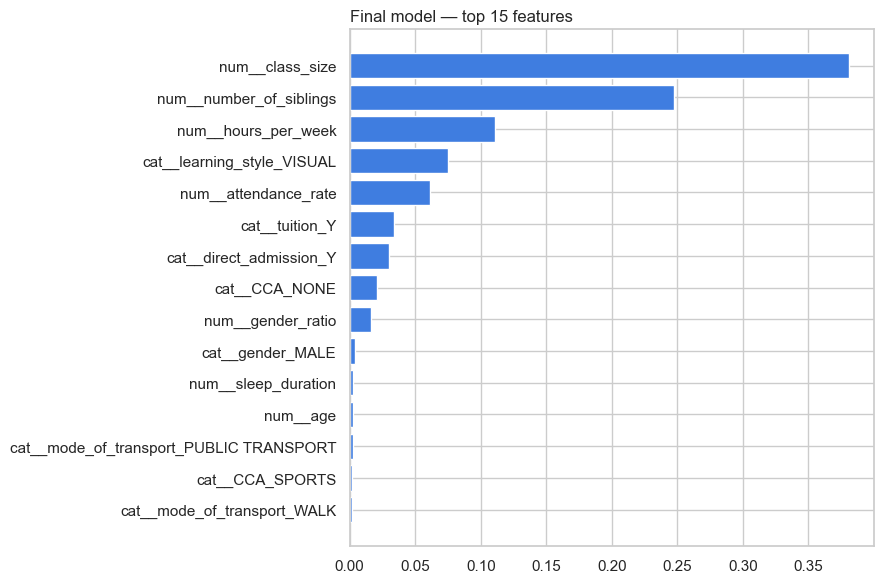

,feature,importance
0,num__class_size,0.380945
1,num__number_of_siblings,0.247053
2,num__hours_per_week,0.110812
3,cat__learning_style_VISUAL,0.074758
4,num__attendance_rate,0.060962
5,cat__tuition_Y,0.033811
6,cat__direct_admission_Y,0.029691
7,cat__CCA_NONE,0.020541
8,num__gender_ratio,0.016426
9,cat__gender_MALE,0.003704


In [78]:
# Feature importance of the final model
names = final_model.named_steps['prep'].get_feature_names_out()
imp = (pd.DataFrame({'feature': names,
                     'importance': final_model.named_steps['reg'].feature_importances_})
       .sort_values('importance', ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 6))
top = imp.head(15).iloc[::-1]
ax.barh(top['feature'], top['importance'], color='#3F7DE0')
ax.set_title('Final model — top 15 features', loc='left')
plt.tight_layout(); plt.show()

imp.head(15)

**Final test performance: RMSE 5.38 | MAE 3.69 | R² 0.850.**

- A **61.3% reduction** in RMSE against the mean-only baseline (13.92 → 5.38).
- Test ≈ validation (5.38 vs 5.13) — the small gap confirms the selection process did
  not overfit the validation set, which is the main risk when a validation set is reused
  across many comparisons as it was here.
- Residuals are centred (mean ≈ 0), roughly symmetric, and close to homoscedastic; the Q-Q plot
  shows mild heavy tails, consistent with a handful of students who over- or
  under-performed relative to every measured feature — which is expected and not
  a modelling defect.
- `class_size` and `number_of_siblings` dominate, followed by `hours_per_week`,
  `learning_style`, and `attendance_rate`. **`bag_color` variants sit at the bottom, as
  the Section 5 negative control predicted** — a useful sanity check that the pipeline is
  not manufacturing signal from noise.

### Reproducing this as a script

The same sequence runs headless via the pipeline:

```bash
python src/Compiler.py
```